In [1]:
import pandas as pd
from pathlib import Path
df = pd.read_parquet(Path().resolve().parent.parent / "processed" / "results" / "L1_sentences2_p08.parquet")#"TALE_qwen3-8B.parquet")

df_L1 = pd.read_parquet(Path().resolve().parent.parent / "processed" / "results" / "L1_p08.parquet")

df_tale = pd.read_parquet(Path().resolve().parent.parent / "processed" / "results" / "TALE_qwen3-8B_no_thinking_reversed.parquet")

df_tale_more_tokens = pd.read_parquet(Path().resolve().parent.parent / "processed" / "results" / "tale_template_p08.parquet")


#### Adherence to the target per dataset

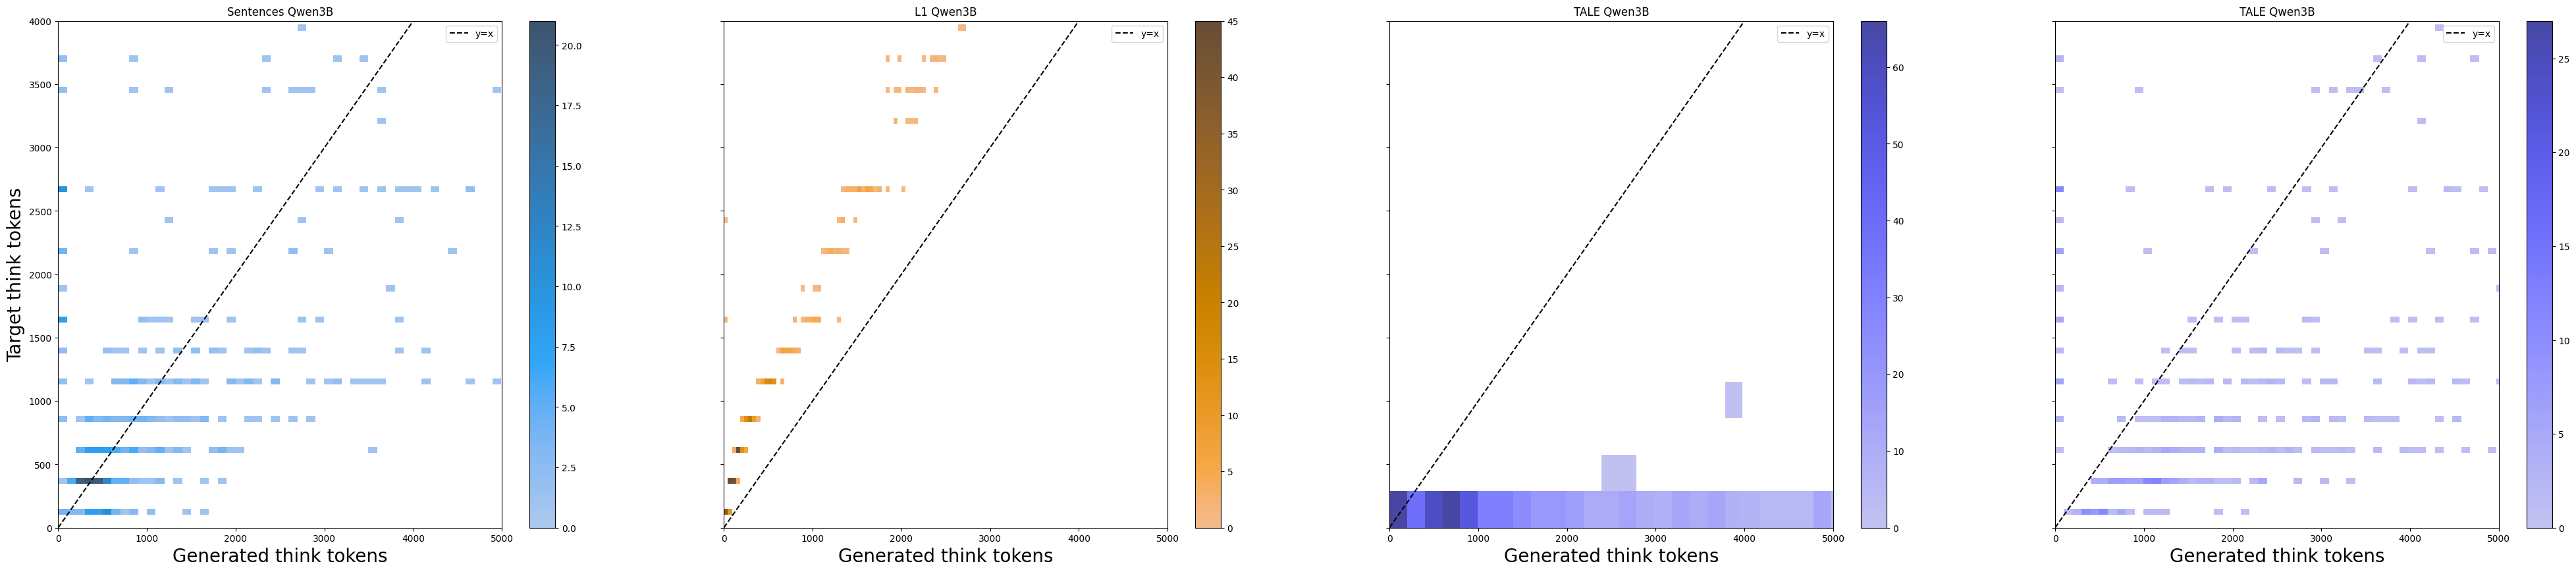

In [11]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 5000, 3)

fig, axes = plt.subplots(1, 4, figsize=(50, 10), sharex=True, sharey=True)


def plot_2d_hist(ax, df_sub, title, color=None, show_ylabel=False):
    df_sub = df_sub[["generated_think_tokens", "target_think_tokens"]].dropna()
    if df_sub.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No samples", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlabel("Generated think tokens")
        ax.set_ylabel("Target think tokens" if show_ylabel else "")
        ax.set_ylim((0, 4000))
        ax.set_xlim((0, 5000))
        ax.plot(x, x, color="black", linestyle="dashed", label="y=x")
        ax.legend()
        return

    sns.histplot(
        df_sub,
        x="generated_think_tokens",
        y="target_think_tokens",
        bins=100,
        pmax=0.9,
        cbar=True,
        ax=ax,
        color=color,
    )
    ax.plot(x, x, color="black", linestyle="dashed", label="y=x")
    ax.set_title(title)
    ax.set_xlabel("Generated think tokens", fontsize=20)
    ax.set_ylabel("Target think tokens" if show_ylabel else "", fontsize=20)
    ax.set_ylim((0, 4000))
    ax.set_xlim((0, 5000))
    ax.legend()

plot_2d_hist(axes[0], df, "Sentences Qwen3B", show_ylabel=True)
plot_2d_hist(axes[1], df_L1, "L1 Qwen3B", color = 'orange', show_ylabel=False)
plot_2d_hist(axes[2], df_tale, "TALE Qwen3B", color = 'blue', show_ylabel=True)
plot_2d_hist(axes[3], df_tale_more_tokens, "TALE Qwen3B", color = 'blue', show_ylabel=False)

plt.savefig("scatter.pdf")
plt.show()


# HIDDEN STATES GENERATION

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "MIG-03c7a8b7-dd9c-5bda-82fb-1cf2e9c3a34d"
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

1
NVIDIA A100-SXM4-80GB MIG 7g.80gb


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = "l3lab/L1-Qwen3-8B-Max"
model_LCPO = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map=device
)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model_LCPO.eval()


In [ ]:
def generate_hidden_states(df):
    
    states = []
    states_ids = []

    for _, q in tqdm(df.iterrows(), total=len(df), desc="Processing rows"):
       
        inputs = tokenizer(q["problem"], return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model_LCPO(**inputs, output_hidden_states=True)
        
        states.append(outputs.hidden_states[-1][:, -1, :].detach().to(torch.float16).cpu().numpy().reshape((-1)))
        states_ids.append(f"{q['dataset']}-{q['id']}")

    states = np.stack(states, axis=0)
    states_ids = np.array(states_ids)

    return states, states_ids

### Generation of evaluation hidden states

In [ ]:
df_eval = pd.read_parquet(f"{DATA_PATH}/raw/eval_data.parquet")
print(df_eval["problem"].iloc[0])
print(df_eval.shape)
df_eval.head()

Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
(2532, 5)


,id,dataset,problem,solution,level
12924,12924,math-500,"Convert the point $(0,3)$ in rectangular coord...",We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also...,2
12925,12925,math-500,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...,We count the number of times $\frac{1}{n^3}$ a...,5
12926,12926,math-500,"If $f(x) = \frac{3x-2}{x-2}$, what is the valu...",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3...,3
12927,12927,math-500,How many positive whole-number divisors does 1...,First prime factorize $196=2^2\cdot7^2$. The ...,3
12928,12928,math-500,The results of a cross-country team's training...,Evelyn covered more distance in less time than...,2


In [ ]:
eval_states, eval_states_ids = generate_hidden_states(df_eval)

Processing rows: 100%|██████████| 2532/2532 [01:49<00:00, 23.04it/s]


In [ ]:
eval_states.shape

(2532, 4096)

In [ ]:
SAVE_PATH = Path().resolve().parent.parent / "processed" / "eval"
SAVE_PATH

PosixPath('/home/s3799042/projects/llm-think-too-much/data/processed/eval')

In [ ]:

np.save(SAVE_PATH / "hidden_states_eval.npy", eval_states)
np.save(SAVE_PATH / "hidden_state_ids_eval.npy", eval_states_ids)